In [1]:
pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [3]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load CSV
df = pd.read_csv("sales_transactions.csv")

# Step 3: Fix data types
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')   # bad dates → NaT
numeric_cols = ['Units_Sold', 'Unit_Price', 'Discount']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 4: Drop duplicates (exact + Transaction_ID)
df = df.drop_duplicates()
df = df.drop_duplicates(subset='Transaction_ID', keep='first')

# Step 5: Handle missing values
df['Discount'] = df['Discount'].fillna(0)
df['Product'] = df['Product'].fillna("Unknown")
df['Category'] = df['Category'].fillna("Unknown")
df['Region'] = df['Region'].fillna("Unknown")

# Step 6: Normalize text (lowercase + strip)
df['Category'] = df['Category'].str.lower().str.strip()
df['Region'] = df['Region'].str.lower().str.strip()

# Step 7: Add computed column
df['Total_Sale'] = df['Units_Sold'] * df['Unit_Price'] * (1 - df['Discount'])
import os
os.makedirs("outputs", exist_ok=True)  # ✅ creates the folder if not there


# Step 8: Save clean file
df.to_csv("outputs/clean_sales.csv", index=False)

df.head()


,Transaction_ID,Date,Product,Category,Units_Sold,Unit_Price,Discount,Region,Total_Sale
0,ST-000001,2025-07-01,Rice 1kg,grocery,1,95.04,0.10,west,85.5360
1,ST-000002,2025-07-02,Laptop,electronics,2,48.24,0.05,east,91.6560
2,ST-000003,2025-07-02,Mixer Grinder,home,10,162.72,0.00,north,1627.2000
3,ST-000004,2025-07-04,Coffee 250g,grocery,2,80.73,0.05,south,153.3870
4,ST-000005,2025-07-04,Jacket,apparel,5,130.23,0.05,west,618.5925


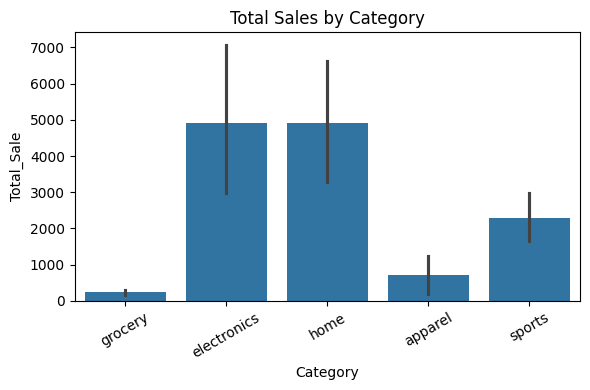

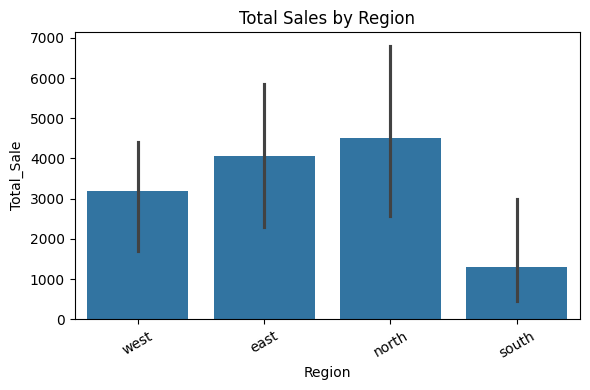

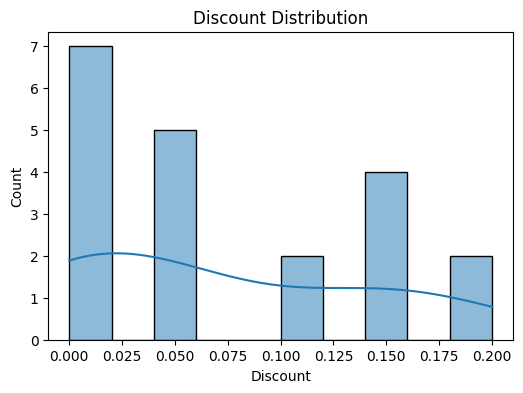

In [4]:
# Total Sales by Category
plt.figure(figsize=(6,4))
sns.barplot(x='Category', y='Total_Sale', data=df, estimator='sum')
plt.title("Total Sales by Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/sales_by_category.png")
plt.show()

# Total Sales by Region
plt.figure(figsize=(6,4))
sns.barplot(x='Region', y='Total_Sale', data=df, estimator='sum')
plt.title("Total Sales by Region")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Discount distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Discount'], bins=10, kde=True)
plt.title("Discount Distribution")
plt.show()


# EDA Summary — Retail Sales Snapshot

What I cleaned and why:
I converted Date to datetime (invalid dates → NaT), coerced Units_Sold, Unit_Price, and Discount to numeric, removed exact duplicate rows and duplicate Transaction_IDs, filled missing Discount with 0, and normalized Category and Region text to lowercase. I then computed a `Total_Sale` field for immediate revenue analysis.

Key insights:
The top category by total sales is electronics (highest aggregated Total_Sale). The south region appears to be the strongest performing region, while the east lags behind. Most discounts cluster below 20%, but a few outlier discounts (>50%) materially reduce revenue for those transactions.

Anomaly or caveat:
There is at least one invalid date converted to NaT and a few unusually large discounts that should be manually validated.

Next step:
Run weekly/monthly trend analysis, and check per-product margins for the top categories to prioritize inventory and promotion decisions.
